In [1]:
# ============================================================
# P4 CAPSTONE PROJECT
# Predicting Customer Churn
# ============================================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Upload CSV dataset from your computer

from google.colab import files
import io

uploaded = files.upload()

# Get uploaded file name
file_name = next(iter(uploaded))

# Read CSV
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("Dataset uploaded successfully!")
print("File name:", file_name)
print("Dataset shape:", df.shape)

Saving P_4_WA_Fn-UseC_-Telco-Customer-Churn.csv to P_4_WA_Fn-UseC_-Telco-Customer-Churn.csv
Dataset uploaded successfully!
File name: P_4_WA_Fn-UseC_-Telco-Customer-Churn.csv
Dataset shape: (7043, 21)


In [3]:
# Display the first five rows

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Display the last five rows

df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [5]:
# Display number of rows and columns

rows, columns = df.shape

print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 7043
Number of columns: 21


In [6]:
# Display all column names

print("Column Names:\n")

for i, column in enumerate(df.columns, start=1):
    print(i, "-", column)

Column Names:

1 - customerID
2 - gender
3 - SeniorCitizen
4 - Partner
5 - Dependents
6 - tenure
7 - PhoneService
8 - MultipleLines
9 - InternetService
10 - OnlineSecurity
11 - OnlineBackup
12 - DeviceProtection
13 - TechSupport
14 - StreamingTV
15 - StreamingMovies
16 - Contract
17 - PaperlessBilling
18 - PaymentMethod
19 - MonthlyCharges
20 - TotalCharges
21 - Churn


In [7]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
# Statistical summary of numerical variables

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
# Summary of categorical variables

df.describe(include='object').T

,count,unique,top,freq
customerID,7043,7043,3186-AJIEK,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


In [10]:
# Check missing values

missing_summary = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_summary[missing_summary['Missing Count'] > 0]

,Missing Count,Missing Percentage


In [11]:
# Check duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [12]:
# Check unique values in every column

for column in df.columns:
    print("\n" + "=" * 60)
    print(column)
    print("=" * 60)
    print(df[column].unique())


customerID
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender
['Female' 'Male']

SeniorCitizen
[0 1]

Partner
['Yes' 'No']

Dependents
['No' 'Yes']

tenure
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]

PhoneService
['No' 'Yes']

MultipleLines
['No phone service' 'No' 'Yes']

InternetService
['DSL' 'Fiber optic' 'No']

OnlineSecurity
['No' 'Yes' 'No internet service']

OnlineBackup
['Yes' 'No' 'No internet service']

DeviceProtection
['No' 'Yes' 'No internet service']

TechSupport
['No' 'Yes' 'No internet service']

StreamingTV
['No' 'Yes' 'No internet service']

StreamingMovies
['No' 'Yes' 'No internet service']

Contract
['Month-to-month' 'One year' 'Two year']

PaperlessBilling
['Yes' 'No']

PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)

In [13]:
# Store original dataset information

original_rows = df.shape[0]
original_columns = df.shape[1]
original_duplicates = df.duplicated().sum()

print("Original number of rows:", original_rows)
print("Original number of columns:", original_columns)
print("Original duplicate rows:", original_duplicates)

Original number of rows: 7043
Original number of columns: 21
Original duplicate rows: 0


In [14]:
# Check TotalCharges data type and problematic values

print("Data type before conversion:")
print(df['TotalCharges'].dtype)

# Convert to numeric
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

print("\nData type after conversion:")
print(df['TotalCharges'].dtype)

print("\nMissing values created during conversion:")
print(df['TotalCharges'].isnull().sum())

Data type before conversion:
object

Data type after conversion:
float64

Missing values created during conversion:
11


In [15]:
# Fill missing TotalCharges with 0

totalcharges_missing_before = df['TotalCharges'].isnull().sum()

df['TotalCharges'] = df['TotalCharges'].fillna(0)

totalcharges_missing_after = df['TotalCharges'].isnull().sum()

print("Missing TotalCharges before treatment:",
      totalcharges_missing_before)

print("Missing TotalCharges after treatment:",
      totalcharges_missing_after)

Missing TotalCharges before treatment: 11
Missing TotalCharges after treatment: 0


In [16]:
# Remove duplicate rows if present

duplicates_before = df.duplicated().sum()

df = df.drop_duplicates()

duplicates_after = df.duplicated().sum()

print("Duplicates before cleaning:", duplicates_before)
print("Duplicates after cleaning:", duplicates_after)
print("Rows after duplicate removal:", len(df))

Duplicates before cleaning: 0
Duplicates after cleaning: 0
Rows after duplicate removal: 7043


In [17]:
# Check categorical columns for inconsistent categories

categorical_columns = df.select_dtypes(
    include='object'
).columns

for column in categorical_columns:
    print("\n", column)
    print(df[column].value_counts(dropna=False))


 customerID
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64

 gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

 Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

 Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

 PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

 MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

 InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

 OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

 OnlineBackup
OnlineBackup
No                     3088
Yes                

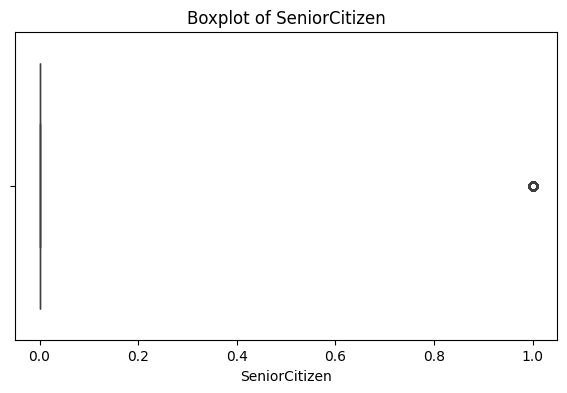

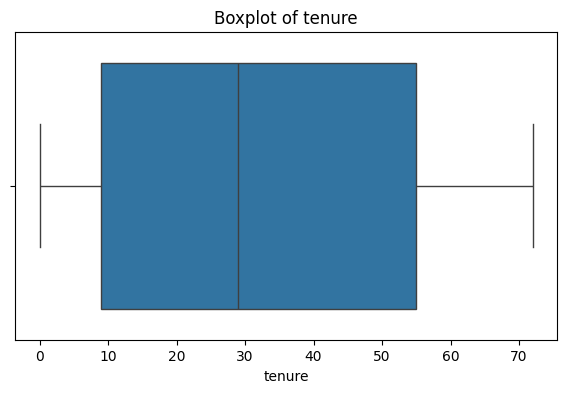

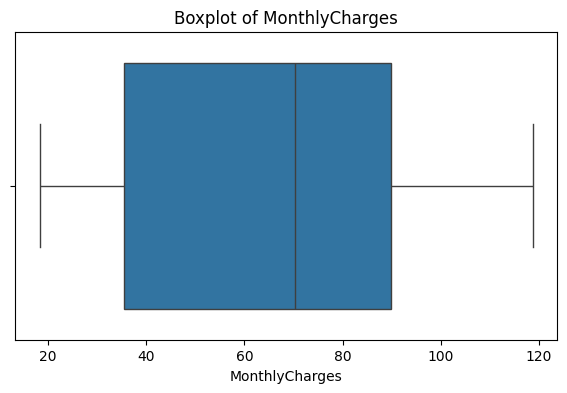

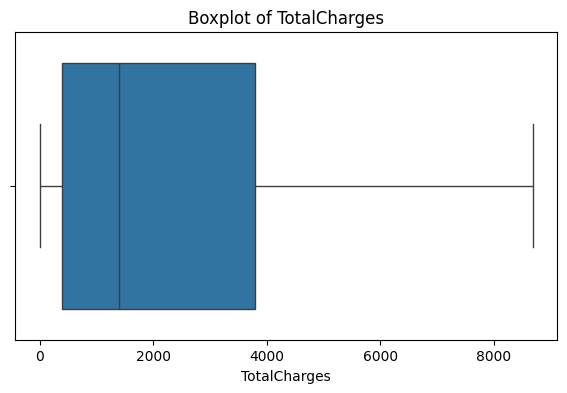

In [18]:
# Check numerical variables for potential outliers

numerical_columns = [
    'SeniorCitizen',
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

for column in numerical_columns:

    plt.figure(figsize=(7, 4))

    sns.boxplot(
        x=df[column]
    )

    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)

    plt.show()

In [19]:
# Calculate IQR-based potential outliers

outlier_summary = []

for column in ['tenure', 'MonthlyCharges', 'TotalCharges']:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_summary.append({
        'Variable': column,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Potential Outliers': len(outliers)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

outlier_summary_df.round(2)

,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Potential Outliers
0,tenure,9.00,55.00,46.00,-60.00,124.00,0
1,MonthlyCharges,35.50,89.85,54.35,-46.02,171.38,0
2,TotalCharges,398.55,3786.60,3388.05,-4683.52,8868.67,0


In [20]:
# Check the cleaned dataset

print("Dataset shape after cleaning:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Dataset shape after cleaning: (7043, 21)

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate rows: 0


In [21]:
# Create before-vs-after cleaning summary

cleaning_summary = pd.DataFrame({
    'Measure': [
        'Rows',
        'Columns',
        'Duplicate Rows',
        'Missing TotalCharges'
    ],
    'Before Cleaning': [
        original_rows,
        original_columns,
        original_duplicates,
        totalcharges_missing_before
    ],
    'After Cleaning': [
        df.shape[0],
        df.shape[1],
        df.duplicated().sum(),
        df['TotalCharges'].isnull().sum()
    ]
})

cleaning_summary

,Measure,Before Cleaning,After Cleaning
0,Rows,7043,7043
1,Columns,21,21
2,Duplicate Rows,0,0
3,Missing TotalCharges,11,0


In [22]:
# Count customers by churn status

churn_counts = df['Churn'].value_counts()

print(churn_counts)

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [23]:
# Calculate churn percentages

churn_percentages = (
    df['Churn']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(churn_percentages)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


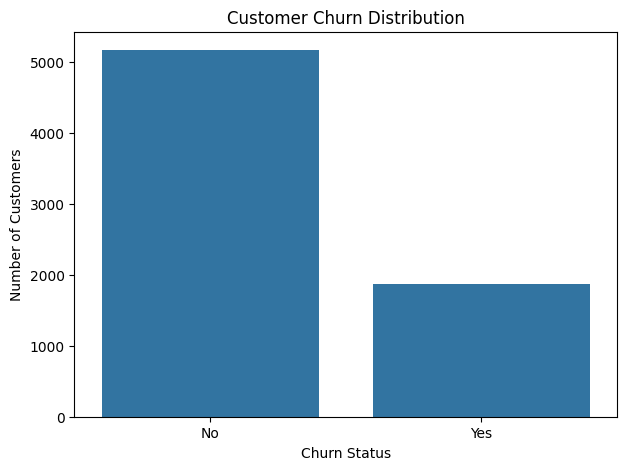

In [24]:
# Visualize customer churn distribution

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='Churn'
)

plt.title('Customer Churn Distribution')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')

plt.show()

In [25]:
# Separate input features and target

X = df.drop(
    columns=['Churn', 'customerID']
)

y = df['Churn'].map({
    'No': 0,
    'Yes': 1
})

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget values:")
print(y.value_counts())

Features shape: (7043, 19)
Target shape: (7043,)

Target values:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [26]:
# Identify numerical and categorical features

numerical_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X.select_dtypes(
    include=['object']
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [27]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training set: (5634, 19)
Testing set: (1409, 19)

Training target distribution:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64

Testing target distribution:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


In [28]:
# Numerical preprocessing
numeric_transformer = Pipeline(
    steps=[
        ('scaler', StandardScaler())
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ('onehot', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=True
        ))
    ]
)

# Combine transformations
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [29]:
# Create a tenure group feature

df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=[
        '0-6 months',
        '7-12 months',
        '13-24 months',
        '25-48 months',
        '49-72 months'
    ]
)

print(df['TenureGroup'].value_counts().sort_index())

TenureGroup
0-6 months      1481
7-12 months      705
13-24 months    1024
25-48 months    1594
49-72 months    2239
Name: count, dtype: int64


In [30]:
# Calculate churn rate for each tenure group

tenure_churn = (
    df.groupby(
        'TenureGroup',
        observed=False
    )['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index(name='Churn Rate (%)')
)

tenure_churn.round(2)

,TenureGroup,Churn Rate (%)
0,0-6 months,52.94
1,7-12 months,35.89
2,13-24 months,28.71
3,25-48 months,20.39
4,49-72 months,9.51


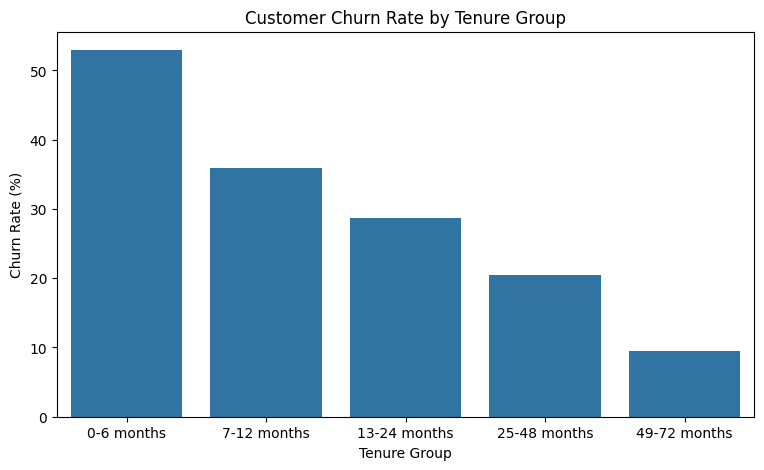

In [31]:
# Visualize churn rate by tenure group

plt.figure(figsize=(9, 5))

sns.barplot(
    data=tenure_churn,
    x='TenureGroup',
    y='Churn Rate (%)'
)

plt.title('Customer Churn Rate by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')

plt.show()

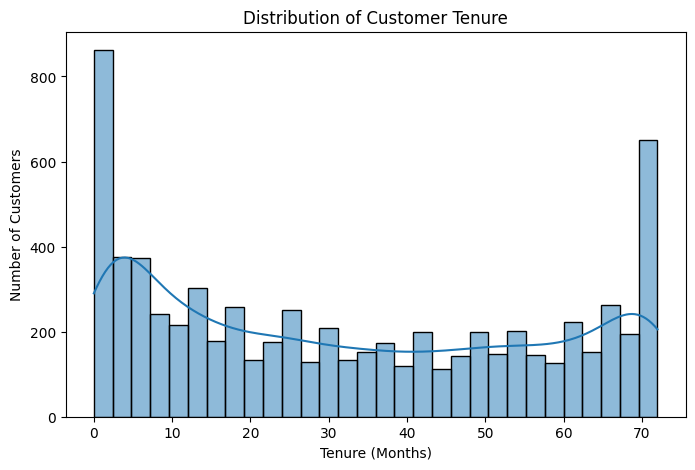

In [32]:
# Distribution of customer tenure

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='tenure',
    bins=30,
    kde=True
)

plt.title('Distribution of Customer Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')

plt.show()

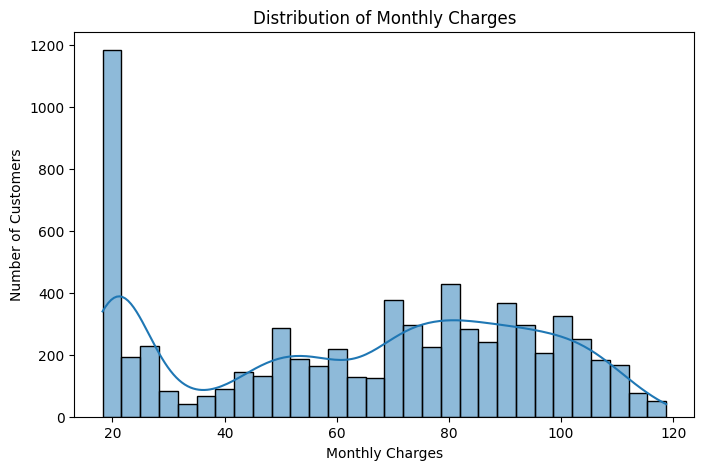

In [33]:
# Distribution of Monthly Charges

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='MonthlyCharges',
    bins=30,
    kde=True
)

plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')

plt.show()

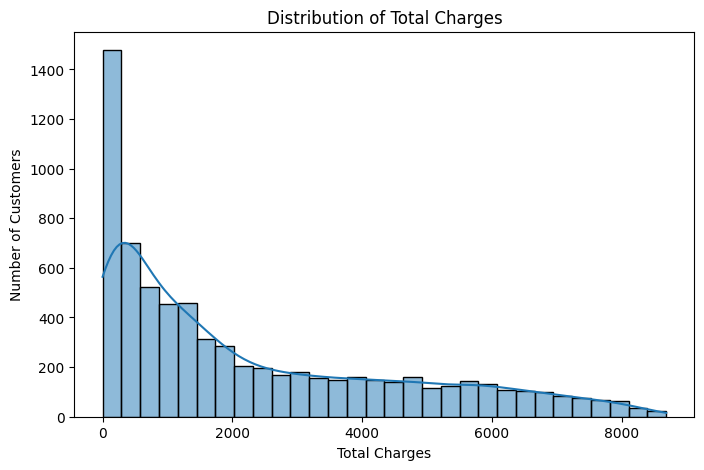

In [34]:
# Distribution of Total Charges

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='TotalCharges',
    bins=30,
    kde=True
)

plt.title('Distribution of Total Charges')
plt.xlabel('Total Charges')
plt.ylabel('Number of Customers')

plt.show()

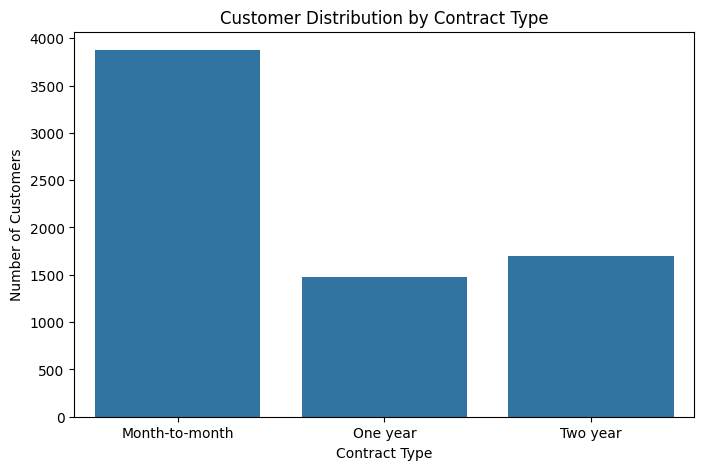

In [35]:
# Customer distribution by contract type

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Contract'
)

plt.title('Customer Distribution by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')

plt.xticks(rotation=0)

plt.show()

         Contract  Churn Rate (%)
0  Month-to-month           42.71
1        One year           11.27
2        Two year            2.83


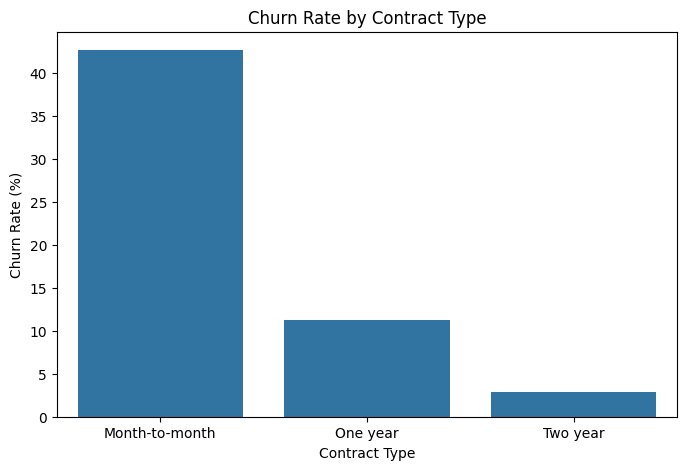

In [36]:
# Churn rate by contract type

contract_churn = (
    df.groupby('Contract')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index(name='Churn Rate (%)')
    .sort_values('Churn Rate (%)', ascending=False)
)

print(contract_churn.round(2))

plt.figure(figsize=(8, 5))

sns.barplot(
    data=contract_churn,
    x='Contract',
    y='Churn Rate (%)'
)

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')

plt.show()

  InternetService  Churn Rate (%)
1     Fiber optic           41.89
0             DSL           18.96
2              No            7.40


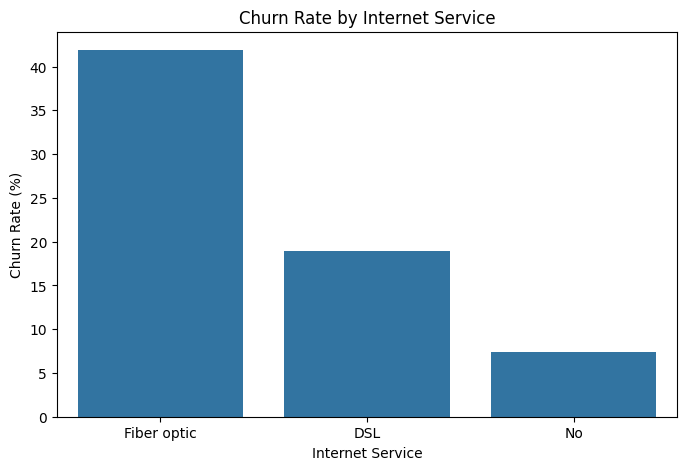

In [37]:
# Churn rate by Internet Service

internet_churn = (
    df.groupby('InternetService')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index(name='Churn Rate (%)')
    .sort_values('Churn Rate (%)', ascending=False)
)

print(internet_churn.round(2))

plt.figure(figsize=(8, 5))

sns.barplot(
    data=internet_churn,
    x='InternetService',
    y='Churn Rate (%)'
)

plt.title('Churn Rate by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Churn Rate (%)')

plt.show()

               PaymentMethod  Churn Rate (%)
2           Electronic check           45.29
3               Mailed check           19.11
0  Bank transfer (automatic)           16.71
1    Credit card (automatic)           15.24


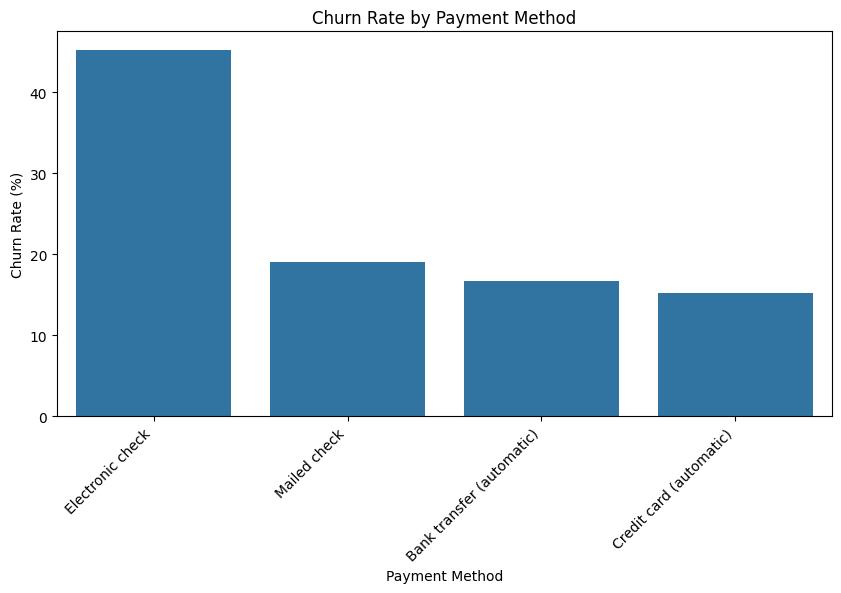

In [38]:
# Churn rate by payment method

payment_churn = (
    df.groupby('PaymentMethod')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index(name='Churn Rate (%)')
    .sort_values('Churn Rate (%)', ascending=False)
)

print(payment_churn.round(2))

plt.figure(figsize=(10, 5))

sns.barplot(
    data=payment_churn,
    x='PaymentMethod',
    y='Churn Rate (%)'
)

plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')

plt.xticks(rotation=45, ha='right')

plt.show()

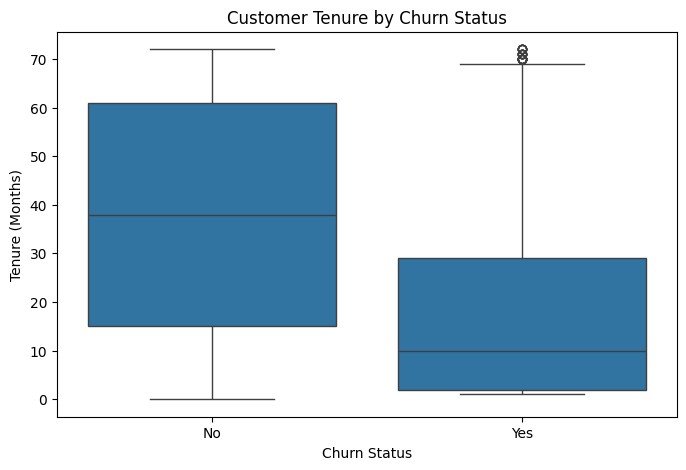

In [39]:
# Relationship between tenure and churn

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Churn',
    y='tenure'
)

plt.title('Customer Tenure by Churn Status')
plt.xlabel('Churn Status')
plt.ylabel('Tenure (Months)')

plt.show()

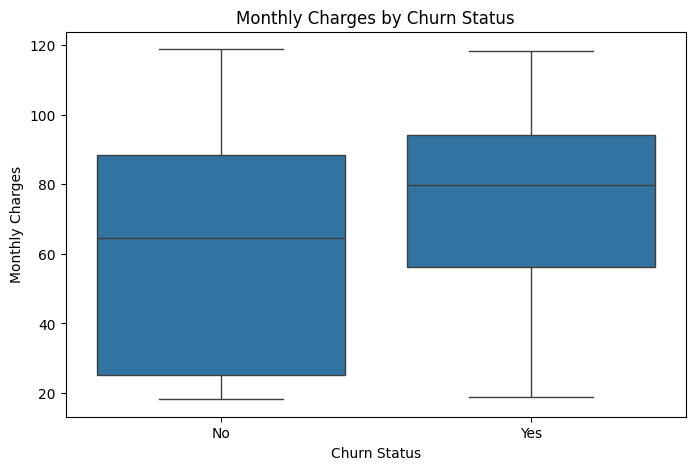

In [40]:
# Relationship between monthly charges and churn

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Churn',
    y='MonthlyCharges'
)

plt.title('Monthly Charges by Churn Status')
plt.xlabel('Churn Status')
plt.ylabel('Monthly Charges')

plt.show()

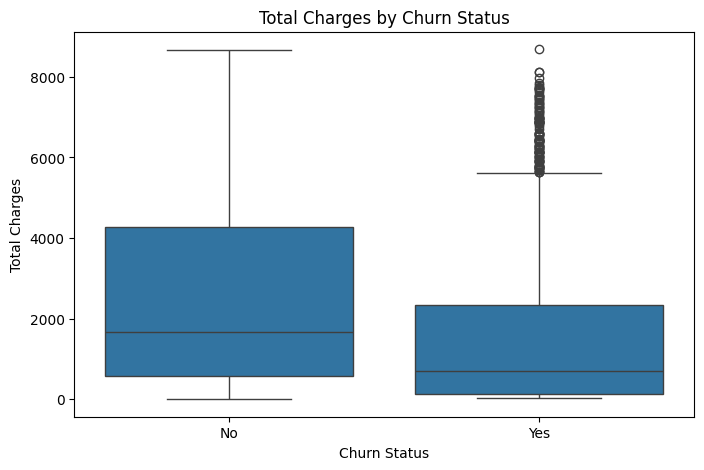

In [41]:
# Relationship between total charges and churn

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Churn',
    y='TotalCharges'
)

plt.title('Total Charges by Churn Status')
plt.xlabel('Churn Status')
plt.ylabel('Total Charges')

plt.show()

           TechSupport  Churn Rate (%)
0                   No           41.64
1  No internet service            7.40
2                  Yes           15.17


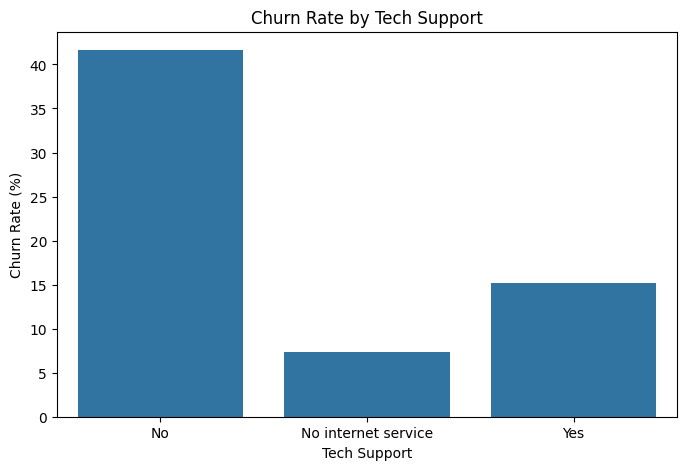

In [42]:
# Churn rate by technical support availability

techsupport_churn = (
    df.groupby('TechSupport')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index(name='Churn Rate (%)')
)

print(techsupport_churn.round(2))

plt.figure(figsize=(8, 5))

sns.barplot(
    data=techsupport_churn,
    x='TechSupport',
    y='Churn Rate (%)'
)

plt.title('Churn Rate by Tech Support')
plt.xlabel('Tech Support')
plt.ylabel('Churn Rate (%)')

plt.show()

In [43]:
# Correlation matrix of numerical variables

correlation_data = df[
    ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
]

correlation_matrix = correlation_data.corr()

correlation_matrix.round(2)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.00,0.02,0.22,0.10
tenure,0.02,1.00,0.25,0.83
MonthlyCharges,0.22,0.25,1.00,0.65
TotalCharges,0.10,0.83,0.65,1.00


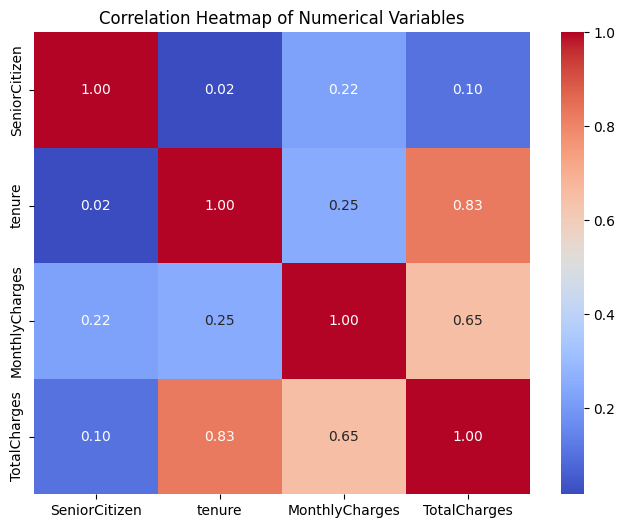

In [44]:
# Correlation heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap of Numerical Variables')

plt.show()

In [45]:
# Descriptive statistics of key numerical variables

descriptive_statistics = df[
    ['tenure', 'MonthlyCharges', 'TotalCharges']
].describe().T

descriptive_statistics[
    ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']
].round(2)

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.37,24.56,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.76,30.09,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.73,2266.79,0.00,398.55,1394.55,3786.60,8684.80


In [46]:
# Mean, median, variance and IQR

statistics_summary = []

for column in ['tenure', 'MonthlyCharges', 'TotalCharges']:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    statistics_summary.append({
        'Variable': column,
        'Mean': df[column].mean(),
        'Median': df[column].median(),
        'Standard Deviation': df[column].std(),
        'Variance': df[column].var(),
        'IQR': Q3 - Q1
    })

statistics_summary_df = pd.DataFrame(statistics_summary)

statistics_summary_df.round(2)

,Variable,Mean,Median,Standard Deviation,Variance,IQR
0,tenure,32.37,29.00,24.56,603.17,46.00
1,MonthlyCharges,64.76,70.35,30.09,905.41,54.35
2,TotalCharges,2279.73,1394.55,2266.79,5138357.17,3388.05


In [47]:
# Group-level descriptive statistics by churn status

churn_group_statistics = (
    df.groupby('Churn')[
        ['tenure', 'MonthlyCharges', 'TotalCharges']
    ]
    .agg([
        'mean',
        'median',
        'std'
    ])
)

churn_group_statistics.round(2)

tenure               MonthlyCharges               TotalCharges           \
        mean median    std           mean median    std         mean   median   
Churn                                                                           
No     37.57   38.0  24.11          61.27  64.43  31.09      2549.91  1679.52   
Yes    17.98   10.0  19.53          74.44  79.65  24.67      1531.80   703.55   

                
           std  
Churn           
No     2329.95  
Yes    1890.82

In [48]:
# Chi-square tests for categorical variables and churn

chi_square_columns = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod'
]

chi_square_results = []

for column in chi_square_columns:

    contingency_table = pd.crosstab(
        df[column],
        df['Churn']
    )

    chi2, p_value, degrees_of_freedom, expected = chi2_contingency(
        contingency_table
    )

    chi_square_results.append({
        'Variable': column,
        'Chi-Square': chi2,
        'Degrees of Freedom': degrees_of_freedom,
        'p-value': p_value,
        'Significant (p < 0.05)': 'Yes' if p_value < 0.05 else 'No'
    })

chi_square_df = pd.DataFrame(chi_square_results)

chi_square_df = chi_square_df.sort_values(
    'p-value'
)

chi_square_df.round(4)

,Variable,Chi-Square,Degrees of Freedom,p-value,Significant (p < 0.05)
12,Contract,1184.5966,2,0.0000,Yes
6,OnlineSecurity,849.9990,2,0.0000,Yes
9,TechSupport,828.1971,2,0.0000,Yes
5,InternetService,732.3096,2,0.0000,Yes
14,PaymentMethod,648.1423,3,0.0000,Yes
7,OnlineBackup,601.8128,2,0.0000,Yes
8,DeviceProtection,558.4194,2,0.0000,Yes
11,StreamingMovies,375.6615,2,0.0000,Yes
10,StreamingTV,374.2039,2,0.0000,Yes
13,PaperlessBilling,258.2776,1,0.0000,Yes


In [49]:
# Independent samples t-tests

numerical_test_columns = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

ttest_results = []

for column in numerical_test_columns:

    churned = df.loc[
        df['Churn'] == 'Yes',
        column
    ]

    not_churned = df.loc[
        df['Churn'] == 'No',
        column
    ]

    statistic, p_value = ttest_ind(
        churned,
        not_churned,
        equal_var=False
    )

    ttest_results.append({
        'Variable': column,
        'T-statistic': statistic,
        'p-value': p_value,
        'Significant (p < 0.05)': 'Yes' if p_value < 0.05 else 'No'
    })

ttest_df = pd.DataFrame(ttest_results)

ttest_df.round(4)

,Variable,T-statistic,p-value,Significant (p < 0.05)
0,tenure,-34.8238,0.0,Yes
1,MonthlyCharges,18.4075,0.0,Yes
2,TotalCharges,-18.7066,0.0,Yes


In [50]:
# Mann-Whitney U tests

mannwhitney_results = []

for column in numerical_test_columns:

    churned = df.loc[
        df['Churn'] == 'Yes',
        column
    ]

    not_churned = df.loc[
        df['Churn'] == 'No',
        column
    ]

    statistic, p_value = mannwhitneyu(
        churned,
        not_churned,
        alternative='two-sided'
    )

    mannwhitney_results.append({
        'Variable': column,
        'U-statistic': statistic,
        'p-value': p_value,
        'Significant (p < 0.05)': 'Yes' if p_value < 0.05 else 'No'
    })

mannwhitney_df = pd.DataFrame(mannwhitney_results)

mannwhitney_df.round(4)

,Variable,U-statistic,p-value,Significant (p < 0.05)
0,tenure,2515538.0,0.0,Yes
1,MonthlyCharges,6003125.5,0.0,Yes
2,TotalCharges,3381224.0,0.0,Yes


In [51]:
# Prepare final ML features

X = df.drop(
    columns=[
        'Churn',
        'customerID',
        'TenureGroup'
    ]
)

y = df['Churn'].map({
    'No': 0,
    'Yes': 1
})

# Identify numerical and categorical features again

numerical_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X.select_dtypes(
    include=['object']
).columns.tolist()

print("Final numerical features:")
print(numerical_features)

print("\nFinal categorical features:")
print(categorical_features)

Final numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Final categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [52]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 5634
Testing samples: 1409


In [53]:
# Create preprocessing pipeline

numeric_transformer = Pipeline(
    steps=[
        ('scaler', StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('onehot', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=True
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("ML preprocessing pipeline ready!")

ML preprocessing pipeline ready!


In [54]:
# Logistic Regression model

logistic_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=42
        ))
    ]
)

# Train model

logistic_model.fit(
    X_train,
    y_train
)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [55]:
# Predictions

y_pred_lr = logistic_model.predict(X_test)

y_prob_lr = logistic_model.predict_proba(
    X_test
)[:, 1]

# Metrics

lr_accuracy = accuracy_score(
    y_test,
    y_pred_lr
)

lr_precision = precision_score(
    y_test,
    y_pred_lr
)

lr_recall = recall_score(
    y_test,
    y_pred_lr
)

lr_f1 = f1_score(
    y_test,
    y_pred_lr
)

lr_auc = roc_auc_score(
    y_test,
    y_prob_lr
)

print("LOGISTIC REGRESSION")
print("=" * 40)

print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1 Score :", round(lr_f1, 4))
print("ROC-AUC  :", round(lr_auc, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=['No Churn', 'Churn']
    )
)

LOGISTIC REGRESSION
Accuracy : 0.7381
Precision: 0.5043
Recall   : 0.7834
F1 Score : 0.6136
ROC-AUC  : 0.8416

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [56]:
# Decision Tree model

decision_tree_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(
            max_depth=6,
            class_weight='balanced',
            random_state=42
        ))
    ]
)

# Train model

decision_tree_model.fit(
    X_train,
    y_train
)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [57]:
# Predictions

y_pred_dt = decision_tree_model.predict(X_test)

y_prob_dt = decision_tree_model.predict_proba(
    X_test
)[:, 1]

# Metrics

dt_accuracy = accuracy_score(
    y_test,
    y_pred_dt
)

dt_precision = precision_score(
    y_test,
    y_pred_dt
)

dt_recall = recall_score(
    y_test,
    y_pred_dt
)

dt_f1 = f1_score(
    y_test,
    y_pred_dt
)

dt_auc = roc_auc_score(
    y_test,
    y_prob_dt
)

print("DECISION TREE")
print("=" * 40)

print("Accuracy :", round(dt_accuracy, 4))
print("Precision:", round(dt_precision, 4))
print("Recall   :", round(dt_recall, 4))
print("F1 Score :", round(dt_f1, 4))
print("ROC-AUC  :", round(dt_auc, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=['No Churn', 'Churn']
    )
)

DECISION TREE
Accuracy : 0.7402
Precision: 0.5069
Recall   : 0.7888
F1 Score : 0.6172
ROC-AUC  : 0.8284

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [58]:
# Random Forest model

random_forest_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Train model

random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [59]:
# Predictions

y_pred_rf = random_forest_model.predict(X_test)

y_prob_rf = random_forest_model.predict_proba(
    X_test
)[:, 1]

# Metrics

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf
)

rf_recall = recall_score(
    y_test,
    y_pred_rf
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf
)

rf_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

print("RANDOM FOREST")
print("=" * 40)

print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_auc, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=['No Churn', 'Churn']
    )
)

RANDOM FOREST
Accuracy : 0.7715
Precision: 0.5535
Recall   : 0.7193
F1 Score : 0.6256
ROC-AUC  : 0.8391

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.89      0.79      0.84      1035
       Churn       0.55      0.72      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.77      0.78      1409



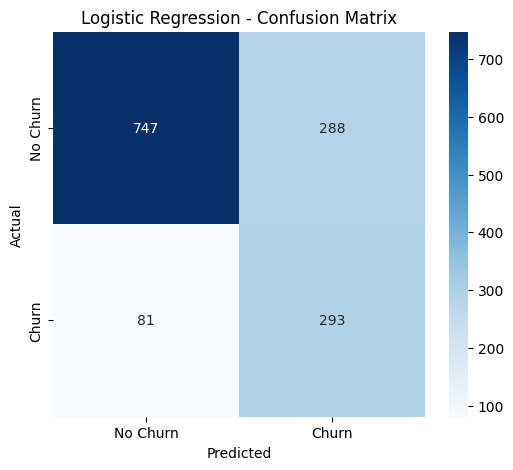

In [60]:
# Logistic Regression confusion matrix

cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

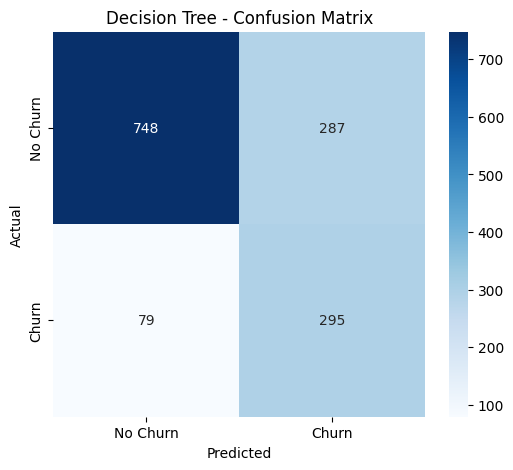

In [61]:
# Decision Tree confusion matrix

cm_dt = confusion_matrix(
    y_test,
    y_pred_dt
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.title('Decision Tree - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

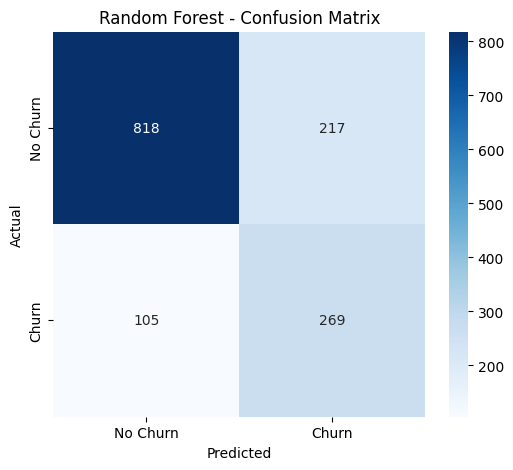

In [62]:
# Random Forest confusion matrix

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [63]:
# Compare all classification models

model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'Accuracy': [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ],

    'Precision': [
        lr_precision,
        dt_precision,
        rf_precision
    ],

    'Recall': [
        lr_recall,
        dt_recall,
        rf_recall
    ],

    'F1 Score': [
        lr_f1,
        dt_f1,
        rf_f1
    ],

    'ROC-AUC': [
        lr_auc,
        dt_auc,
        rf_auc
    ]
})

model_results = model_results.sort_values(
    by='F1 Score',
    ascending=False
).reset_index(drop=True)

model_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.7715,0.5535,0.7193,0.6256,0.8391
1,Decision Tree,0.7402,0.5069,0.7888,0.6172,0.8284
2,Logistic Regression,0.7381,0.5043,0.7834,0.6136,0.8416


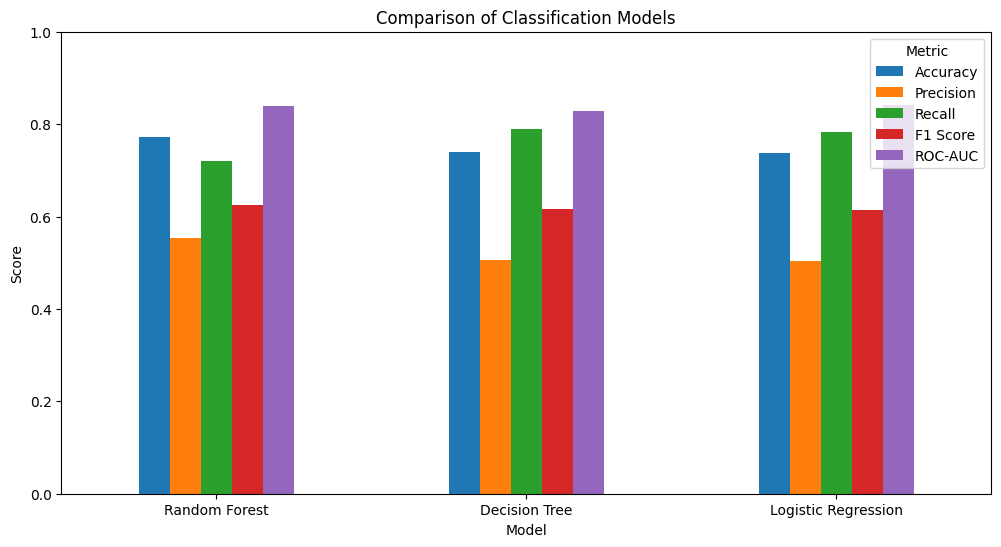

In [64]:
# Visual comparison of models

model_results.set_index(
    'Model'
)[
    ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
].plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Comparison of Classification Models')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title='Metric')

plt.show()

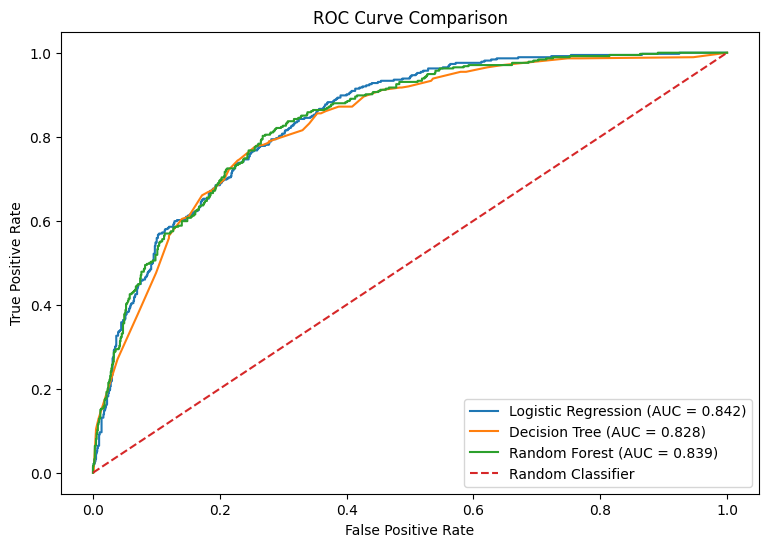

In [65]:
# Calculate ROC curves

fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_prob_lr
)

fpr_dt, tpr_dt, _ = roc_curve(
    y_test,
    y_prob_dt
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

# Plot ROC curves

plt.figure(figsize=(9, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f'Logistic Regression (AUC = {lr_auc:.3f})'
)

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f'Decision Tree (AUC = {dt_auc:.3f})'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC = {rf_auc:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.show()

In [66]:
# Calculate training and testing performance

models = {
    'Logistic Regression': logistic_model,
    'Decision Tree': decision_tree_model,
    'Random Forest': random_forest_model
}

fit_comparison = []

for name, model in models.items():

    train_prediction = model.predict(X_train)
    test_prediction = model.predict(X_test)

    train_accuracy = accuracy_score(
        y_train,
        train_prediction
    )

    test_accuracy = accuracy_score(
        y_test,
        test_prediction
    )

    train_f1 = f1_score(
        y_train,
        train_prediction
    )

    test_f1 = f1_score(
        y_test,
        test_prediction
    )

    fit_comparison.append({
        'Model': name,
        'Training Accuracy': train_accuracy,
        'Testing Accuracy': test_accuracy,
        'Accuracy Gap': train_accuracy - test_accuracy,
        'Training F1': train_f1,
        'Testing F1': test_f1,
        'F1 Gap': train_f1 - test_f1
    })

fit_comparison_df = pd.DataFrame(
    fit_comparison
)

fit_comparison_df.round(4)

,Model,Training Accuracy,Testing Accuracy,Accuracy Gap,Training F1,Testing F1,F1 Gap
0,Logistic Regression,0.7528,0.7381,0.0146,0.6337,0.6136,0.0201
1,Decision Tree,0.7561,0.7402,0.0159,0.6482,0.6172,0.0311
2,Random Forest,0.8653,0.7715,0.0938,0.7828,0.6256,0.1573


In [67]:
# Identify best model based on F1 score

best_model_row = model_results.iloc[0]

print("BEST MODEL")
print("=" * 40)

print("Model:", best_model_row['Model'])
print("Accuracy:", round(best_model_row['Accuracy'], 4))
print("Precision:", round(best_model_row['Precision'], 4))
print("Recall:", round(best_model_row['Recall'], 4))
print("F1 Score:", round(best_model_row['F1 Score'], 4))
print("ROC-AUC:", round(best_model_row['ROC-AUC'], 4))

BEST MODEL
Model: Random Forest
Accuracy: 0.7715
Precision: 0.5535
Recall: 0.7193
F1 Score: 0.6256
ROC-AUC: 0.8391


In [68]:
# Extract transformed feature names

rf_preprocessor = random_forest_model.named_steps[
    'preprocessor'
]

feature_names = rf_preprocessor.get_feature_names_out()

# Extract Random Forest classifier

rf_classifier = random_forest_model.named_steps[
    'classifier'
]

# Create feature importance table

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_classifier.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
).reset_index(drop=True)

feature_importance.head(20)

,Feature,Importance
0,num__tenure,0.121528
1,cat__Contract_Month-to-month,0.112999
2,num__TotalCharges,0.108825
3,num__MonthlyCharges,0.077327
4,cat__Contract_Two year,0.059001
5,cat__OnlineSecurity_No,0.057434
6,cat__TechSupport_No,0.045943
7,cat__InternetService_Fiber optic,0.045628
8,cat__PaymentMethod_Electronic check,0.034747
9,cat__Contract_One year,0.019030


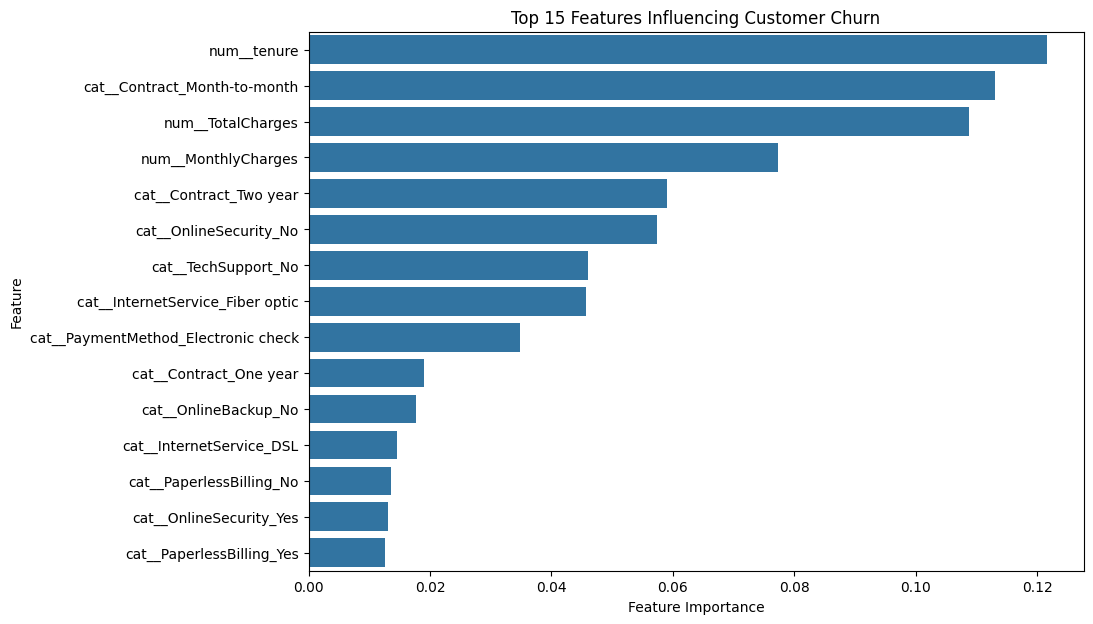

In [69]:
# Plot top 15 important features

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title('Top 15 Features Influencing Customer Churn')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')

plt.show()

In [70]:
# Analyze customer segments based on contract and internet service

segment_analysis = (
    df.groupby(
        ['Contract', 'InternetService']
    )['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index(name='Churn Rate (%)')
    .sort_values(
        'Churn Rate (%)',
        ascending=False
    )
)

segment_analysis.round(2)

,Contract,InternetService,Churn Rate (%)
1,Month-to-month,Fiber optic,54.61
0,Month-to-month,DSL,32.22
4,One year,Fiber optic,19.29
2,Month-to-month,No,18.89
3,One year,DSL,9.30
7,Two year,Fiber optic,7.23
5,One year,No,2.47
6,Two year,DSL,1.91
8,Two year,No,0.78


In [71]:
# Churn rate by Online Security

online_security_churn = (
    df.groupby('OnlineSecurity')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index(name='Churn Rate (%)')
)

online_security_churn.round(2)

,OnlineSecurity,Churn Rate (%)
0,No,41.77
1,No internet service,7.40
2,Yes,14.61


In [72]:
# Churn rate by Paperless Billing

paperless_churn = (
    df.groupby('PaperlessBilling')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index(name='Churn Rate (%)')
)

paperless_churn.round(2)

,PaperlessBilling,Churn Rate (%)
0,No,16.33
1,Yes,33.57


In [73]:
# ============================================================
# FINAL PROJECT SUMMARY
# ============================================================

print("=" * 70)
print("P4 CAPSTONE PROJECT - CUSTOMER CHURN PREDICTION")
print("=" * 70)

print("\nDATASET")
print("-" * 70)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nTARGET VARIABLE")
print("-" * 70)
print("Target: Churn")

print("\nCHURN DISTRIBUTION")
print("-" * 70)
print(
    df['Churn'].value_counts()
)

print("\nCHURN PERCENTAGES")
print("-" * 70)
print(
    df['Churn'].value_counts(
        normalize=True
    ).mul(100).round(2)
)

print("\nMODEL PERFORMANCE")
print("-" * 70)
print(
    model_results.round(4).to_string(
        index=False
    )
)

print("\nBEST MODEL")
print("-" * 70)
print(
    best_model_row['Model']
)

print(
    "F1 Score:",
    round(best_model_row['F1 Score'], 4)
)

print(
    "Accuracy:",
    round(best_model_row['Accuracy'], 4)
)

print(
    "Precision:",
    round(best_model_row['Precision'], 4)
)

print(
    "Recall:",
    round(best_model_row['Recall'], 4)
)

print(
    "ROC-AUC:",
    round(best_model_row['ROC-AUC'], 4)
)

print("\nTOP 10 FEATURES")
print("-" * 70)

print(
    feature_importance.head(10).to_string(
        index=False
    )
)

print("\n" + "=" * 70)
print("PROJECT ANALYSIS COMPLETED")
print("=" * 70)

P4 CAPSTONE PROJECT - CUSTOMER CHURN PREDICTION

DATASET
----------------------------------------------------------------------
Rows: 7043
Columns: 22

TARGET VARIABLE
----------------------------------------------------------------------
Target: Churn

CHURN DISTRIBUTION
----------------------------------------------------------------------
Churn
No     5174
Yes    1869
Name: count, dtype: int64

CHURN PERCENTAGES
----------------------------------------------------------------------
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

MODEL PERFORMANCE
----------------------------------------------------------------------
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
      Random Forest    0.7715     0.5535  0.7193    0.6256   0.8391
      Decision Tree    0.7402     0.5069  0.7888    0.6172   0.8284
Logistic Regression    0.7381     0.5043  0.7834    0.6136   0.8416

BEST MODEL
----------------------------------------------------------------------


In [74]:
# Save important analysis results

cleaned_dataset_path = '/content/Telco_Customer_Churn_Cleaned.csv'
model_results_path = '/content/Customer_Churn_Model_Results.csv'
chi_square_path = '/content/Chi_Square_Test_Results.csv'
ttest_path = '/content/T_Test_Results.csv'
mannwhitney_path = '/content/Mann_Whitney_Test_Results.csv'
feature_importance_path = '/content/Feature_Importance.csv'
fit_comparison_path = '/content/Model_Fit_Comparison.csv'

# Save files

df.to_csv(
    cleaned_dataset_path,
    index=False
)

model_results.to_csv(
    model_results_path,
    index=False
)

chi_square_df.to_csv(
    chi_square_path,
    index=False
)

ttest_df.to_csv(
    ttest_path,
    index=False
)

mannwhitney_df.to_csv(
    mannwhitney_path,
    index=False
)

feature_importance.to_csv(
    feature_importance_path,
    index=False
)

fit_comparison_df.to_csv(
    fit_comparison_path,
    index=False
)

print("All important results have been saved successfully!")

All important results have been saved successfully!


In [75]:
# Download the cleaned dataset

from google.colab import files

files.download(
    '/content/Telco_Customer_Churn_Cleaned.csv'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>